In [557]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
file_path = r"E:\Uniforce '25\Next Bike Cycle Hire - Stirling Trip Data (2018-2023).csv"
df = pd.read_csv(file_path)

In [558]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156456 entries, 0 to 156455
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Start time    156456 non-null  object 
 1   End time      156456 non-null  object 
 2   Duration      156456 non-null  int64  
 3   Duration.1    156456 non-null  float64
 4   Rental_Place  156456 non-null  object 
 5   Return_Place  156456 non-null  object 
 6   START LAT     156456 non-null  float64
 7   START LONG    156456 non-null  float64
 8   END LAT       156456 non-null  float64
 9   END LONG      156456 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 11.9+ MB


,Start time,End time,Duration,Duration.1,Rental_Place,Return_Place,START LAT,START LONG,END LAT,END LONG
0,2018-01-01T03:33:00.000Z,2018-01-01T03:49:00.000Z,978,16.30,TRAIN STATION,TRAIN STATION,56.11945,-3.93537,56.11945,-3.93537
1,2018-01-01T04:49:00.000Z,2018-01-01T04:56:00.000Z,424,7.07,OLD STIRLING BRIDGE,BRIDGE OF ALLAN,56.12954,-3.93506,56.15297,-3.94723
2,2018-01-01T22:02:00.000Z,2018-01-01T22:19:00.000Z,1053,17.55,BRIDGE OF ALLAN,OLD STIRLING BRIDGE,56.15297,-3.94723,56.12954,-3.93506
3,2018-01-02T16:20:00.000Z,2018-01-02T17:02:00.000Z,2536,42.27,THE BACK WALK,BORESTONE ROUNDABOUT,56.11781,-3.93948,56.10034,-3.93702
4,2018-01-02T16:21:00.000Z,2018-01-02T17:02:00.000Z,2468,41.13,THE BACK WALK,BORESTONE ROUNDABOUT,56.11781,-3.93948,56.10034,-3.93702


In [559]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [560]:
df.columns

Index(['start_time', 'end_time', 'duration', 'duration.1', 'rental_place',
       'return_place', 'start_lat', 'start_long', 'end_lat', 'end_long'],
      dtype='object')

In [561]:
df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")


In [562]:
df[["start_time", "end_time"]].isna().sum()


start_time    0
end_time      0
dtype: int64

In [563]:
df = df.dropna(subset=["start_time", "end_time"])


In [564]:
df["duration_minutes"] = df["duration"] / 60


In [565]:
df = df.drop(columns=["duration", "duration.1"])


In [566]:
df.columns

Index(['start_time', 'end_time', 'rental_place', 'return_place', 'start_lat',
       'start_long', 'end_lat', 'end_long', 'duration_minutes'],
      dtype='object')

In [567]:
df

,start_time,end_time,rental_place,return_place,start_lat,start_long,end_lat,end_long,duration_minutes
0,2018-01-01 03:33:00+00:00,2018-01-01 03:49:00+00:00,TRAIN STATION,TRAIN STATION,56.11945,-3.93537,56.11945,-3.93537,16.300000
1,2018-01-01 04:49:00+00:00,2018-01-01 04:56:00+00:00,OLD STIRLING BRIDGE,BRIDGE OF ALLAN,56.12954,-3.93506,56.15297,-3.94723,7.066667
2,2018-01-01 22:02:00+00:00,2018-01-01 22:19:00+00:00,BRIDGE OF ALLAN,OLD STIRLING BRIDGE,56.15297,-3.94723,56.12954,-3.93506,17.550000
3,2018-01-02 16:20:00+00:00,2018-01-02 17:02:00+00:00,THE BACK WALK,BORESTONE ROUNDABOUT,56.11781,-3.93948,56.10034,-3.93702,42.266667
4,2018-01-02 16:21:00+00:00,2018-01-02 17:02:00+00:00,THE BACK WALK,BORESTONE ROUNDABOUT,56.11781,-3.93948,56.10034,-3.93702,41.133333
...,...,...,...,...,...,...,...,...,...
156451,2023-10-31 22:27:00+00:00,2023-10-31 22:46:00+00:00,TRAIN STATION,BRIDGE OF ALLAN,56.11899,-3.93650,56.15297,-3.94720,19.550000
156452,2023-10-31 22:31:00+00:00,2023-10-31 22:36:00+00:00,CAUSEWAYHEAD ROUNDABOUT,OLD STIRLING BRIDGE,56.13829,-3.92390,56.12954,-3.93500,4.766667
156453,2023-10-31 22:41:00+00:00,2023-10-31 22:51:00+00:00,OLD STIRLING BRIDGE,TRAIN STATION,56.12954,-3.93500,56.11899,-3.93650,9.433333
156454,2023-10-31 22:44:00+00:00,2023-10-31 22:56:00+00:00,TRAIN STATION,TRAIN STATION,56.11899,-3.93650,56.11899,-3.93650,11.766667


In [568]:
df = df[
    (df["duration_minutes"] >= 2) &
    (df["duration_minutes"] <= 180)
]


In [569]:
df.duplicated().sum()


np.int64(0)

In [570]:
df = df.drop_duplicates()


In [571]:
df["rental_place"] = df["rental_place"].str.upper().str.strip()
df["return_place"] = df["return_place"].str.upper().str.strip()


In [572]:
df["rental_place"].nunique(), df["return_place"].nunique()


(38, 58)

In [573]:
df["start_hour"] = df["start_time"].dt.hour
df["start_day"] = df["start_time"].dt.day_name()
df["start_month"] = df["start_time"].dt.month
df["start_year"] = df["start_time"].dt.year


In [574]:
df["is_peak"] = df["start_hour"].between(14, 18)

In [575]:
geo_cols = ["start_lat", "start_long", "end_lat", "end_long"]
df[geo_cols].describe()

,start_lat,start_long,end_lat,end_long
count,140689.000000,140689.000000,140689.000000,140689.000000
mean,56.133859,-3.931873,56.133785,-3.932705
std,0.014199,0.011374,0.014158,0.011427
min,56.090130,-3.967030,55.867400,-4.340000
25%,56.119450,-3.936560,56.119450,-3.936560
50%,56.129800,-3.935060,56.129800,-3.935060
75%,56.147640,-3.921510,56.147640,-3.923920
max,56.156850,-3.906600,56.251380,-3.740000


In [576]:
df = df[
    df["start_lat"].between(55, 57) &
    df["end_lat"].between(55, 57)
]

In [577]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 140689 entries, 0 to 156455
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   start_time        140689 non-null  datetime64[ns, UTC]
 1   end_time          140689 non-null  datetime64[ns, UTC]
 2   rental_place      140689 non-null  object             
 3   return_place      140689 non-null  object             
 4   start_lat         140689 non-null  float64            
 5   start_long        140689 non-null  float64            
 6   end_lat           140689 non-null  float64            
 7   end_long          140689 non-null  float64            
 8   duration_minutes  140689 non-null  float64            
 9   start_hour        140689 non-null  int32              
 10  start_day         140689 non-null  object             
 11  start_month       140689 non-null  int32              
 12  start_year        140689 non-null  int32         

,start_lat,start_long,end_lat,end_long,duration_minutes,start_hour,start_month,start_year
count,140689.000000,140689.000000,140689.000000,140689.000000,140689.000000,140689.000000,140689.000000,140689.000000
mean,56.133859,-3.931873,56.133785,-3.932705,19.224907,14.056955,6.567507,2020.178863
std,0.014199,0.011374,0.014158,0.011427,20.340865,5.065621,3.163892,1.750812
min,56.090130,-3.967030,55.867400,-4.340000,2.000000,0.000000,1.000000,2018.000000
25%,56.119450,-3.936560,56.119450,-3.936560,9.066667,11.000000,4.000000,2019.000000
50%,56.129800,-3.935060,56.129800,-3.935060,13.633333,15.000000,7.000000,2020.000000
75%,56.147640,-3.921510,56.147640,-3.923920,20.716667,18.000000,9.000000,2022.000000
max,56.156850,-3.906600,56.251380,-3.740000,180.000000,23.000000,12.000000,2023.000000


In [578]:
df.head()

,start_time,end_time,rental_place,return_place,start_lat,start_long,end_lat,end_long,duration_minutes,start_hour,start_day,start_month,start_year,is_peak
0,2018-01-01 03:33:00+00:00,2018-01-01 03:49:00+00:00,TRAIN STATION,TRAIN STATION,56.11945,-3.93537,56.11945,-3.93537,16.300000,3,Monday,1,2018,False
1,2018-01-01 04:49:00+00:00,2018-01-01 04:56:00+00:00,OLD STIRLING BRIDGE,BRIDGE OF ALLAN,56.12954,-3.93506,56.15297,-3.94723,7.066667,4,Monday,1,2018,False
2,2018-01-01 22:02:00+00:00,2018-01-01 22:19:00+00:00,BRIDGE OF ALLAN,OLD STIRLING BRIDGE,56.15297,-3.94723,56.12954,-3.93506,17.550000,22,Monday,1,2018,False
3,2018-01-02 16:20:00+00:00,2018-01-02 17:02:00+00:00,THE BACK WALK,BORESTONE ROUNDABOUT,56.11781,-3.93948,56.10034,-3.93702,42.266667,16,Tuesday,1,2018,True
4,2018-01-02 16:21:00+00:00,2018-01-02 17:02:00+00:00,THE BACK WALK,BORESTONE ROUNDABOUT,56.11781,-3.93948,56.10034,-3.93702,41.133333,16,Tuesday,1,2018,True


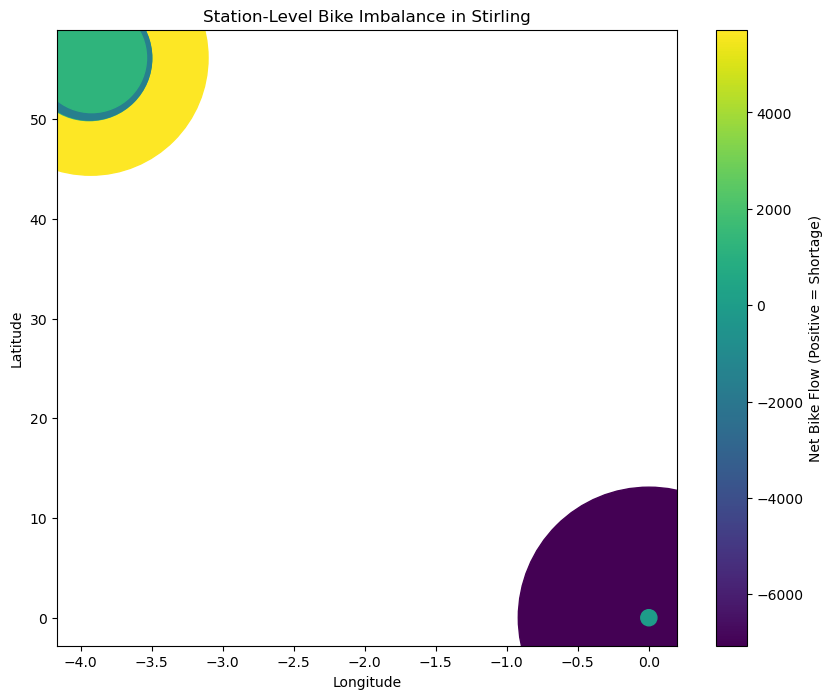

In [579]:
plt.figure(figsize=(10,8))

plt.scatter(
    stations["lon"],
    stations["lat"],
    s=stations["net_flow"].abs() * 5,
    c=stations["net_flow"],
)

plt.colorbar(label="Net Bike Flow (Positive = Shortage)")
plt.title("Station-Level Bike Imbalance in Stirling")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
# Shows demand analysis is location based rather than normal

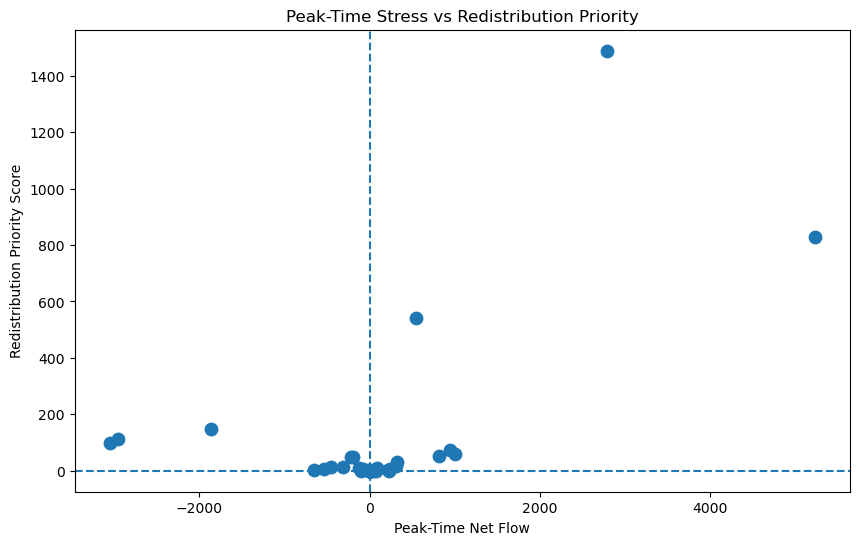

In [580]:
plt.figure(figsize=(10,6))

plt.scatter(
    stations["peak_net_flow"],
    stations["redistribution_priority"],
    s=80,
)

plt.axhline(stations["redistribution_priority"].median(), linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Peak-Time Net Flow")
plt.ylabel("Redistribution Priority Score")
plt.title("Peak-Time Stress vs Redistribution Priority")
plt.show()


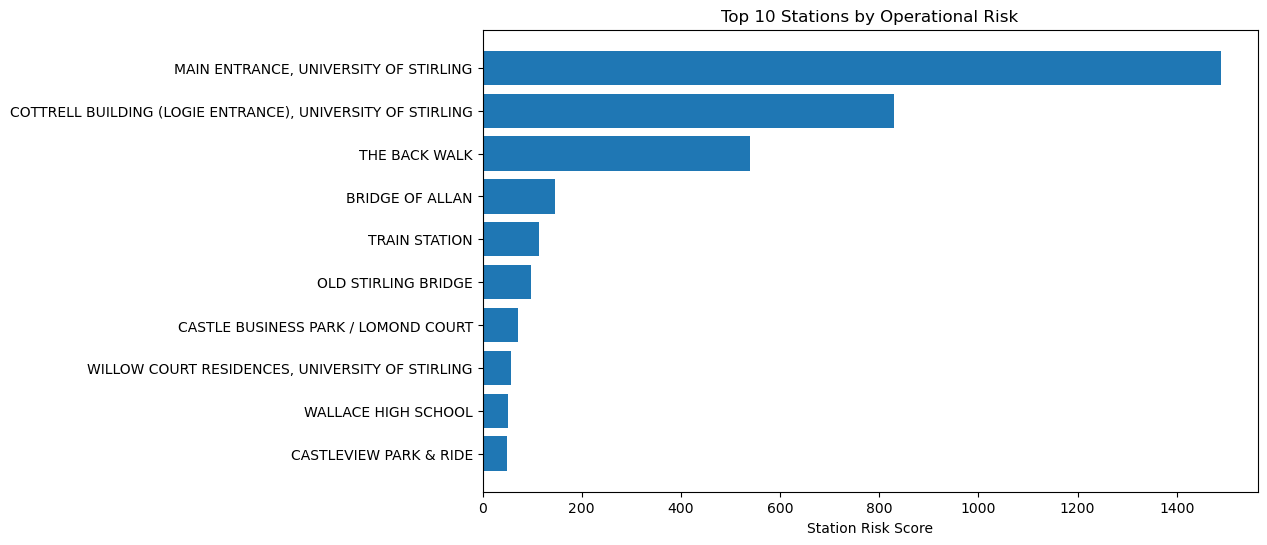

In [581]:
stations["risk_score"] = (
    stations["peak_net_flow"].abs() *
    stations["imbalance_ratio"].abs()
)

top_risk = stations.sort_values("risk_score", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_risk["station"], top_risk["risk_score"])
plt.xlabel("Station Risk Score")
plt.title("Top 10 Stations by Operational Risk")
plt.gca().invert_yaxis()
plt.show()


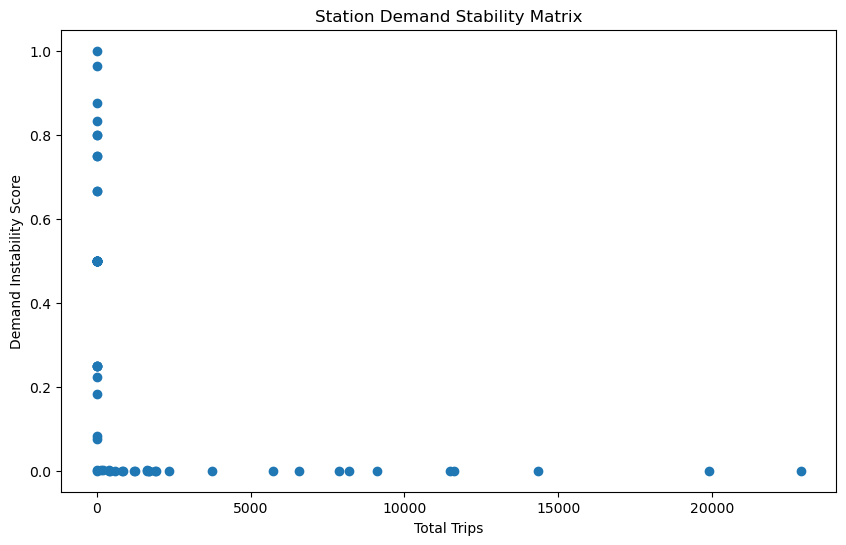

In [582]:
stations["stability_score"] = (
    stations["imbalance_ratio"].abs() /
    (stations["trips_started"] + 1)
)

plt.figure(figsize=(10,6))
plt.scatter(
    stations["trips_started"],
    stations["stability_score"],
)

plt.xlabel("Total Trips")
plt.ylabel("Demand Instability Score")
plt.title("Station Demand Stability Matrix")
plt.show()


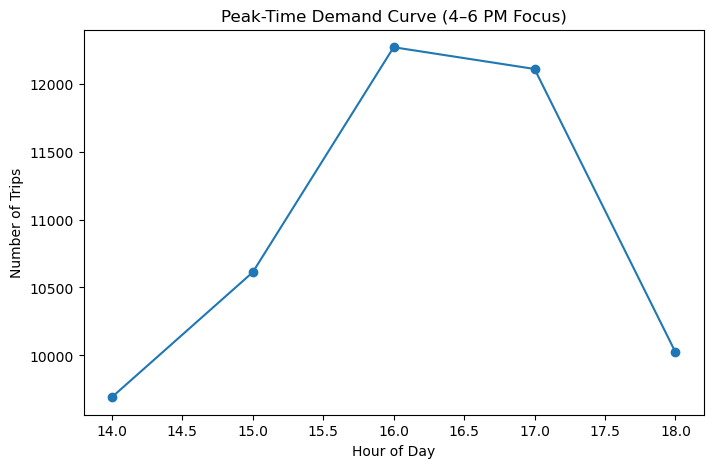

In [583]:
peak_hourly = (
    df[df["is_peak"] == True]
    .groupby("start_hour")
    .size()
)

plt.figure(figsize=(8,5))
peak_hourly.plot(kind="line", marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Peak-Time Demand Curve (4–6 PM Focus)")
plt.show()


In [584]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = stations[[
    "trips_started",
    "net_flow",
    "peak_net_flow",
    "imbalance_ratio"
]]

scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
stations["cluster"] = kmeans.fit_predict(scaled)


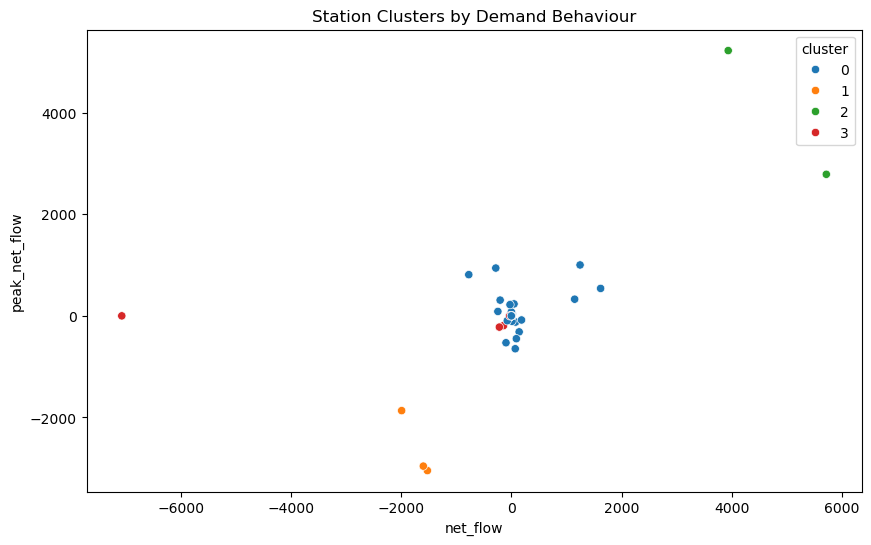

In [585]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=stations,
    x="net_flow",
    y="peak_net_flow",
    hue="cluster",
    palette="tab10"
)
plt.title("Station Clusters by Demand Behaviour")
plt.show()


In [586]:
df.to_csv("Next bike Stirling 2018 - 2023.csv", index=False)

In [587]:
import os
print(os.getcwd())


C:\Users\Muhammad imran


In [588]:
df = pd.read_csv("Next bike Stirling 2018 - 2023.csv", parse_dates=["start_time", "end_time"])

In [589]:
starts = (
    df.groupby("rental_place")
    .size()
    .reset_index(name="trips_started")
)

ends = (
    df.groupby("return_place")
    .size()
    .reset_index(name="trips_ended")
)

In [590]:
station_demand = pd.merge(
    starts,
    ends,
    left_on="rental_place",
    right_on="return_place",
    how="outer"
).fillna(0)


In [591]:
station_demand["station"] = station_demand["rental_place"].combine_first(
    station_demand["return_place"]
)

station_demand = station_demand[[
    "station", "trips_started", "trips_ended"
]]


In [592]:
station_demand["net_flow"] = (
    station_demand["trips_started"] -
    station_demand["trips_ended"]
)


In [593]:
station_demand["imbalance_ratio"] = (
    station_demand["net_flow"] /
    (station_demand["trips_started"] + station_demand["trips_ended"] + 1)
)


In [594]:
coords_start = (
    df.groupby("rental_place")[["start_lat", "start_long"]]
    .median()
    .reset_index()
)

coords_end = (
    df.groupby("return_place")[["end_lat", "end_long"]]
    .median()
    .reset_index()
)

coords_start.columns = ["station", "lat", "lon"]
coords_end.columns = ["station", "lat", "lon"]

coords = pd.concat([coords_start, coords_end]).drop_duplicates("station")

In [595]:
station_demand = station_demand.merge(coords, on="station", how="left")

In [596]:
station_demand.sort_values("net_flow", ascending=False).head(10)
# Worst shortages

,station,trips_started,trips_ended,net_flow,imbalance_ratio,lat,lon
26,"MAIN ENTRANCE, UNIVERSITY OF STIRLING",8207.0,2491.0,5716.0,0.534256,56.14764,-3.92882
15,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",14347.0,10411.0,3936.0,0.158972,56.14397,-3.92084
57,THE BACK WALK,1621.0,0.0,1621.0,0.999383,56.11781,-3.93948
64,"WILLOW COURT RESIDENCES, UNIVERSITY OF STIRLING",11485.0,10237.0,1248.0,0.057451,56.14917,-3.92151
2,"ALEXANDER COURT RESIDENCES, UNIVERSITY OF STIR...",6564.0,5414.0,1150.0,0.096001,56.14893,-3.90660
13,COMMUNITY HOSPITAL,1222.0,1036.0,186.0,0.082337,56.10701,-3.93676
6,BORESTONE ROUNDABOUT,1886.0,1743.0,143.0,0.039394,56.10034,-3.93702
8,BRIDGE OF ALLAN TRAIN STATION,1643.0,1551.0,92.0,0.028795,56.15685,-3.95705
4,BANNOCKBURN TOWN CENTRE,602.0,523.0,79.0,0.070160,56.09013,-3.91239
27,MURRAY PLACE,9097.0,9025.0,72.0,0.003973,56.11901,-3.93656


In [597]:
station_demand.sort_values("net_flow").head(10)


,station,trips_started,trips_ended,net_flow,imbalance_ratio,lat,lon
25,0,0.0,7067.0,-7067.0,-0.999859,NaN,NaN
7,BRIDGE OF ALLAN,11624.0,13613.0,-1989.0,-0.078810,56.15297,-3.94723
59,TRAIN STATION,19907.0,21503.0,-1596.0,-0.038540,56.11945,-3.93537
32,OLD STIRLING BRIDGE,22888.0,24410.0,-1522.0,-0.032178,56.12954,-3.93506
63,WALLACE HIGH SCHOOL,5737.0,6508.0,-771.0,-0.062959,56.14011,-3.92694
10,CASTLE BUSINESS PARK / LOMOND COURT,1702.0,1983.0,-281.0,-0.076234,56.12820,-3.96029
37,"PATHFOOT BUILDING, UNIVERSITY OF STIRLING",840.0,1083.0,-243.0,-0.126299,56.14840,-3.92701
41,SPRINGKERSE PARK & RIDE,391.0,607.0,-216.0,-0.216216,56.11470,-3.90739
17,FORTH VALLEY COLLEGE,1688.0,1890.0,-202.0,-0.056440,56.13300,-3.96113
11,CASTLEVIEW PARK & RIDE,208.0,348.0,-140.0,-0.251346,56.13104,-3.96703


In [598]:
peak_df = df[df["is_peak"] == True]

In [599]:
peak_starts = peak_df.groupby("rental_place").size()
peak_ends = peak_df.groupby("return_place").size()

peak_balance = (
    peak_starts
    .sub(peak_ends, fill_value=0)
    .reset_index(name="peak_net_flow")
    .rename(columns={"index": "station"})
)

In [600]:
station_demand = station_demand.merge(
    peak_balance, on="station", how="left"
).fillna(0)


In [601]:
station_demand["redistribution_priority"] = (
    station_demand["peak_net_flow"].abs() *
    station_demand["imbalance_ratio"].abs()
)


In [602]:
station_demand.sort_values(
    "redistribution_priority", ascending=False
).head(10)


,station,trips_started,trips_ended,net_flow,imbalance_ratio,lat,lon,peak_net_flow,redistribution_priority
26,"MAIN ENTRANCE, UNIVERSITY OF STIRLING",8207.0,2491.0,5716.0,0.534256,56.14764,-3.92882,2786.0,1488.435929
15,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",14347.0,10411.0,3936.0,0.158972,56.14397,-3.92084,5221.0,829.995396
57,THE BACK WALK,1621.0,0.0,1621.0,0.999383,56.11781,-3.93948,540.0,539.667078
7,BRIDGE OF ALLAN,11624.0,13613.0,-1989.0,-0.078810,56.15297,-3.94723,-1865.0,146.980149
59,TRAIN STATION,19907.0,21503.0,-1596.0,-0.038540,56.11945,-3.93537,-2957.0,113.964212
32,OLD STIRLING BRIDGE,22888.0,24410.0,-1522.0,-0.032178,56.12954,-3.93506,-3045.0,97.982833
10,CASTLE BUSINESS PARK / LOMOND COURT,1702.0,1983.0,-281.0,-0.076234,56.12820,-3.96029,941.0,71.736571
64,"WILLOW COURT RESIDENCES, UNIVERSITY OF STIRLING",11485.0,10237.0,1248.0,0.057451,56.14917,-3.92151,1002.0,57.565530
63,WALLACE HIGH SCHOOL,5737.0,6508.0,-771.0,-0.062959,56.14011,-3.92694,811.0,51.060020
11,CASTLEVIEW PARK & RIDE,208.0,348.0,-140.0,-0.251346,56.13104,-3.96703,-192.0,48.258528


In [603]:
station_demand.to_csv(
    "nextbike_station_demand_analysis.csv", index=False
)


In [604]:
import os
print(os.getcwd())


C:\Users\Muhammad imran


In [605]:
df = pd.read_csv("Next bike Stirling 2018 - 2023.csv", parse_dates=["start_time"])
stations = pd.read_csv("nextbike_station_demand_analysis.csv")

In [606]:
peak_df = df[df["is_peak"] == True].copy()


In [607]:
hourly_balance = (
    peak_df
    .groupby(["rental_place", "start_hour"])
    .size()
    .unstack(fill_value=0)
)

hourly_returns = (
    peak_df
    .groupby(["return_place", "start_hour"])
    .size()
    .unstack(fill_value=0)
)

hourly_net = hourly_balance.sub(hourly_returns, fill_value=0)
hourly_net
# Hourly net-flow per station

start_hour,14,15,16,17,18
"(INOFF) PATHFOOT BUILDING, UNIVERSITY OF STIRLING",0.0,0.0,0.0,0.0,1.0
(INOFF.) UNIVERSITY OF STIRLING,0.0,0.0,0.0,1.0,0.0
"ALEXANDER COURT RESIDENCES, UNIVERSITY OF STIRLING",172.0,80.0,46.0,9.0,21.0
BANNOCKBURN HIGH SCHOOL,-5.0,10.0,10.0,2.0,22.0
BANNOCKBURN TOWN CENTRE,2.0,-14.0,-14.0,-30.0,-66.0
BIKE PARKING AT COTTRELL BUILDING,0.0,1.0,0.0,0.0,0.0
BORESTONE ROUNDABOUT,18.0,36.0,-58.0,-134.0,-177.0
BRIDGE OF ALLAN,-76.0,-285.0,-378.0,-462.0,-664.0
BRIDGE OF ALLAN TRAIN STATION,-57.0,-97.0,-239.0,-83.0,27.0
"BRIDGE OF ALLAN, STIRLING, SCOTLAND, FK9 4HR, UNITED KINGDOM",-1.0,-2.0,-2.0,-1.0,0.0


In [608]:
critical_shortages = hourly_net[hourly_net.max(axis=1) >= 2]
critical_shortages
# Just the university is facing severe shortages

start_hour,14,15,16,17,18
"ALEXANDER COURT RESIDENCES, UNIVERSITY OF STIRLING",172.0,80.0,46.0,9.0,21.0
BANNOCKBURN HIGH SCHOOL,-5.0,10.0,10.0,2.0,22.0
BANNOCKBURN TOWN CENTRE,2.0,-14.0,-14.0,-30.0,-66.0
BORESTONE ROUNDABOUT,18.0,36.0,-58.0,-134.0,-177.0
BRIDGE OF ALLAN TRAIN STATION,-57.0,-97.0,-239.0,-83.0,27.0
CASTLE BUSINESS PARK / LOMOND COURT,130.0,67.0,262.0,371.0,111.0
CAUSEWAYHEAD ROUNDABOUT,-26.0,9.0,0.0,145.0,102.0
COMMUNITY HOSPITAL,-79.0,17.0,10.0,-7.0,-22.0
"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY OF STIRLING",518.0,883.0,1774.0,1264.0,782.0
FORTH VALLEY COLLEGE,51.0,93.0,198.0,-41.0,9.0


In [609]:
bikes_needed = (
    hourly_net.clip(lower=0)
    .sum(axis=1)
    .reset_index()
)

bikes_needed.columns = ["station", "bikes_required"]
bikes_needed.sort_values("bikes_required", ascending=False)


,station,bikes_required
14,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",5221.0
21,"MAIN ENTRANCE, UNIVERSITY OF STIRLING",2786.0
50,"WILLOW COURT RESIDENCES, UNIVERSITY OF STIRLING",1002.0
49,WALLACE HIGH SCHOOL,962.0
10,CASTLE BUSINESS PARK / LOMOND COURT,941.0
44,THE BACK WALK,540.0
16,FORTH VALLEY COLLEGE,351.0
2,"ALEXANDER COURT RESIDENCES, UNIVERSITY OF STIR...",328.0
12,CAUSEWAYHEAD ROUNDABOUT,256.0
38,STIRLING HIGH SCHOOL,245.0


In [610]:
surplus_stations = (
    hourly_net.clip(upper=0).abs()
    .sum(axis=1)
    .reset_index()
)

surplus_stations.columns = ["station", "surplus_bikes"]
surplus_stations.sort_values("surplus_bikes", ascending=False)

,station,surplus_bikes
23,OLD STIRLING BRIDGE,3045.0
46,TRAIN STATION,2957.0
20,MAIN ENTRANCE STIRLING UNI,2175.0
7,BRIDGE OF ALLAN,1865.0
22,MURRAY PLACE,647.0
29,RAPLOCH COMMUNITY CAMPUS,529.0
8,BRIDGE OF ALLAN TRAIN STATION,476.0
6,BORESTONE ROUNDABOUT,369.0
31,SPRINGKERSE PARK & RIDE,224.0
11,CASTLEVIEW PARK & RIDE,192.0


In [611]:
shortage = bikes_needed.sort_values("bikes_required", ascending=False)
surplus = surplus_stations.sort_values("surplus_bikes", ascending=False)

redistribution_plan = []

for _, s in shortage.iterrows():
    needed = s["bikes_required"]
    for _, p in surplus.iterrows():
        if needed <= 0:
            break
        move = min(needed, p["surplus_bikes"])
        if move > 0:
            redistribution_plan.append([
                p["station"], s["station"], move
            ])
            needed -= move


In [612]:
redistribution_df = pd.DataFrame(
    redistribution_plan,
    columns=["from_station", "to_station", "bikes_to_move"]
)


In [613]:
redistribution_df = redistribution_df.groupby(
    ["from_station", "to_station"]
)["bikes_to_move"].sum().reset_index()

redistribution_df.sort_values(
    "bikes_to_move", ascending=False
).head(10)
# Low cost moves (Priortized)

,from_station,to_station,bikes_to_move
11,OLD STIRLING BRIDGE,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",3045.0
13,OLD STIRLING BRIDGE,"MAIN ENTRANCE, UNIVERSITY OF STIRLING",2786.0
29,TRAIN STATION,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",2176.0
28,OLD STIRLING BRIDGE,"WILLOW COURT RESIDENCES, UNIVERSITY OF STIRLING",1002.0
27,OLD STIRLING BRIDGE,WALLACE HIGH SCHOOL,962.0
8,OLD STIRLING BRIDGE,CASTLE BUSINESS PARK / LOMOND COURT,941.0
24,OLD STIRLING BRIDGE,THE BACK WALK,540.0
12,OLD STIRLING BRIDGE,FORTH VALLEY COLLEGE,351.0
2,OLD STIRLING BRIDGE,"ALEXANDER COURT RESIDENCES, UNIVERSITY OF STIR...",328.0
9,OLD STIRLING BRIDGE,CAUSEWAYHEAD ROUNDABOUT,256.0


In [614]:
stations["norm_peak_flow"] = (
    stations["peak_net_flow"].abs() /
    stations["peak_net_flow"].abs().max()
)

stations["norm_imbalance"] = (
    stations["imbalance_ratio"].abs() /
    stations["imbalance_ratio"].abs().max()
)

In [615]:
stations[[
    "peak_net_flow",
    "norm_peak_flow",
    "imbalance_ratio",
    "norm_imbalance"
]].head()


,peak_net_flow,norm_peak_flow,imbalance_ratio,norm_imbalance
0,1.0,0.000192,0.500000,0.500071
1,1.0,0.000192,0.500000,0.500071
2,328.0,0.062823,0.096001,0.096015
3,39.0,0.007470,0.018244,0.018247
4,-122.0,0.023367,0.070160,0.070170


In [616]:
stations["station_risk_score"] = (
    0.6 * stations["norm_peak_flow"] +
    0.4 * stations["norm_imbalance"]
)

stations.sort_values(
    "station_risk_score", ascending=False
)

,station,trips_started,trips_ended,net_flow,imbalance_ratio,lat,lon,peak_net_flow,redistribution_priority,norm_peak_flow,norm_imbalance,station_risk_score
15,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",14347.0,10411.0,3936.0,0.158972,56.14397,-3.92084,5221.0,829.995396,1.000000,0.158995,0.663598
26,"MAIN ENTRANCE, UNIVERSITY OF STIRLING",8207.0,2491.0,5716.0,0.534256,56.14764,-3.92882,2786.0,1488.435929,0.533614,0.534331,0.533901
57,THE BACK WALK,1621.0,0.0,1621.0,0.999383,56.11781,-3.93948,540.0,539.667078,0.103428,0.999525,0.461867
25,0,0.0,7067.0,-7067.0,-0.999859,0.00000,0.00000,0.0,0.000000,0.000000,1.000000,0.400000
60,0,0.0,27.0,-27.0,-0.964286,0.00000,0.00000,0.0,0.000000,0.000000,0.964422,0.385769
...,...,...,...,...,...,...,...,...,...,...,...,...
58,THE PEAK,1924.0,1997.0,-73.0,-0.018613,56.11820,-3.91407,-96.0,1.786843,0.018387,0.018616,0.018479
38,PORT STREET,2347.0,2334.0,13.0,0.002777,56.11538,-3.93741,-106.0,0.294319,0.020303,0.002777,0.013292
3,BANNOCKBURN HIGH SCHOOL,446.0,430.0,16.0,0.018244,56.09590,-3.92244,39.0,0.711517,0.007470,0.018247,0.011781
48,STIRLING COUNCIL OLD VIEWFORTH,405.0,404.0,1.0,0.001235,56.11312,-3.93639,79.0,0.097531,0.015131,0.001235,0.009573


In [617]:
stations["marginal_impact_per_bike"] = (
    stations["peak_net_flow"].abs() /
    (stations["redistribution_priority"] + 1)
)

stations.sort_values(
    "marginal_impact_per_bike", ascending=False
).head(10)


,station,trips_started,trips_ended,net_flow,imbalance_ratio,lat,lon,peak_net_flow,redistribution_priority,norm_peak_flow,norm_imbalance,station_risk_score,marginal_impact_per_bike
12,CAUSEWAYHEAD ROUNDABOUT,7869.0,7873.0,-4.0,-0.000254,56.13829,-3.92392,230.0,0.058439,0.044053,0.000254,0.026533,217.301206
27,MURRAY PLACE,9097.0,9025.0,72.0,0.003973,56.11901,-3.93656,-647.0,2.570435,0.123923,0.003973,0.075943,181.210395
38,PORT STREET,2347.0,2334.0,13.0,0.002777,56.11538,-3.93741,-106.0,0.294319,0.020303,0.002777,0.013292,81.896370
56,TEITH HOUSE,1236.0,1259.0,-23.0,-0.009215,56.11289,-3.92586,221.0,2.036458,0.042329,0.009216,0.029084,72.782161
48,STIRLING COUNCIL OLD VIEWFORTH,405.0,404.0,1.0,0.001235,56.11312,-3.93639,79.0,0.097531,0.015131,0.001235,0.009573,71.979753
39,RAPLOCH COMMUNITY CAMPUS,3764.0,3860.0,-96.0,-0.012590,56.12980,-3.94921,-529.0,6.660197,0.101322,0.012592,0.065830,69.058279
58,THE PEAK,1924.0,1997.0,-73.0,-0.018613,56.11820,-3.91407,-96.0,1.786843,0.018387,0.018616,0.018479,34.447575
8,BRIDGE OF ALLAN TRAIN STATION,1643.0,1551.0,92.0,0.028795,56.15685,-3.95705,-449.0,12.928951,0.085999,0.028799,0.063119,32.235018
32,OLD STIRLING BRIDGE,22888.0,24410.0,-1522.0,-0.032178,56.12954,-3.93506,-3045.0,97.982833,0.583222,0.032183,0.362806,30.762910
49,STIRLING HIGH SCHOOL,854.0,804.0,50.0,0.030139,56.10479,-3.94630,235.0,7.082580,0.045011,0.030143,0.039063,29.074875


In [618]:
peak_df = df[df["is_peak"] == True]

peak_counts = (
    peak_df.groupby(["rental_place", "start_hour"])
    .size()
    .unstack(fill_value=0)
)

shortage_probability = (
    (peak_counts > peak_counts.mean()).sum(axis=1) /
    peak_counts.shape[1]
)

shortage_probability = shortage_probability.reset_index()
shortage_probability.columns = ["station", "shortage_risk_probability"]

shortage_probability.sort_values(
    "shortage_risk_probability", ascending=False
).head(10)

,station,shortage_risk_probability
2,"ALEXANDER COURT RESIDENCES, UNIVERSITY OF STIR...",1.0
16,MURRAY PLACE,1.0
7,BRIDGE OF ALLAN,1.0
33,WALLACE HIGH SCHOOL,1.0
11,CAUSEWAYHEAD ROUNDABOUT,1.0
13,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",1.0
17,OLD STIRLING BRIDGE,1.0
15,"MAIN ENTRANCE, UNIVERSITY OF STIRLING",1.0
34,"WILLOW COURT RESIDENCES, UNIVERSITY OF STIRLING",1.0
31,TRAIN STATION,1.0


In [619]:
stations = stations.merge(
    shortage_probability, on="station", how="left"
).fillna(0)


In [620]:
volatility = peak_counts.std(axis=1).reset_index()
volatility.columns = ["station", "volatility_index"]

stations = stations.merge(
    volatility, on="station", how="left"
).fillna(0)

stations.sort_values(
    "volatility_index", ascending=False
).head(10)


,station,trips_started,trips_ended,net_flow,imbalance_ratio,lat,lon,peak_net_flow,redistribution_priority,norm_peak_flow,norm_imbalance,station_risk_score,marginal_impact_per_bike,shortage_risk_probability,volatility_index
15,"COTTRELL BUILDING (LOGIE ENTRANCE), UNIVERSITY...",14347.0,10411.0,3936.0,0.158972,56.14397,-3.92084,5221.0,829.995396,1.000000,0.158995,0.663598,6.282827,1.0,447.583177
63,WALLACE HIGH SCHOOL,5737.0,6508.0,-771.0,-0.062959,56.14011,-3.92694,811.0,51.060020,0.155334,0.062968,0.118388,15.578173,1.0,167.323937
10,CASTLE BUSINESS PARK / LOMOND COURT,1702.0,1983.0,-281.0,-0.076234,56.12820,-3.96029,941.0,71.736571,0.180234,0.076245,0.138638,12.937096,0.2,122.342552
26,"MAIN ENTRANCE, UNIVERSITY OF STIRLING",8207.0,2491.0,5716.0,0.534256,56.14764,-3.92882,2786.0,1488.435929,0.533614,0.534331,0.533901,1.870507,1.0,120.269281
64,"WILLOW COURT RESIDENCES, UNIVERSITY OF STIRLING",11485.0,10237.0,1248.0,0.057451,56.14917,-3.92151,1002.0,57.565530,0.191917,0.057459,0.138134,17.109040,1.0,93.901544
17,FORTH VALLEY COLLEGE,1688.0,1890.0,-202.0,-0.056440,56.13300,-3.96113,310.0,17.496507,0.059376,0.056448,0.058205,16.759921,0.0,92.700054
59,TRAIN STATION,19907.0,21503.0,-1596.0,-0.038540,56.11945,-3.93537,-2957.0,113.964212,0.566367,0.038546,0.355238,25.721048,1.0,89.951098
12,CAUSEWAYHEAD ROUNDABOUT,7869.0,7873.0,-4.0,-0.000254,56.13829,-3.92392,230.0,0.058439,0.044053,0.000254,0.026533,217.301206,1.0,84.493787
32,OLD STIRLING BRIDGE,22888.0,24410.0,-1522.0,-0.032178,56.12954,-3.93506,-3045.0,97.982833,0.583222,0.032183,0.362806,30.762910,1.0,76.389135
27,MURRAY PLACE,9097.0,9025.0,72.0,0.003973,56.11901,-3.93656,-647.0,2.570435,0.123923,0.003973,0.075943,181.210395,1.0,68.878879


In [621]:
total_shortage = bikes_needed["bikes_required"].sum()
total_moved = redistribution_df["bikes_to_move"].sum()

coverage_rate = total_moved / total_shortage
coverage_rate
# This will tell us the redistribution Impact

np.float64(1.0)

In [622]:
redistribution_df.to_csv(
    "nextbike_peak_redistribution_plan.csv", index=False
)

bikes_needed.to_csv(
    "nextbike_peak_bikes_required.csv", index=False
)

In [623]:
import os
print(os.getcwd())


C:\Users\Muhammad imran


In [624]:
import pandas as pd
import numpy as np

df = pd.read_csv("Next bike Stirling 2018 - 2023.csv", parse_dates=["start_time"])
stations = pd.read_csv("nextbike_station_demand_analysis.csv")
redistribution = pd.read_csv("nextbike_peak_redistribution_plan.csv")


In [625]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

df["distance_km"] = df.apply(
    lambda x: haversine(
        x["start_lat"], x["start_long"],
        x["end_lat"], x["end_long"]
    ),
    axis=1
)


In [626]:
CO2_PER_KM = 0.171  # kg

df["co2_saved_kg"] = df["distance_km"] * CO2_PER_KM


In [627]:
co2_summary = {
    "total_trips": len(df),
    "total_co2_saved_tonnes": df["co2_saved_kg"].sum() / 1000,
    "avg_co2_saved_per_trip_kg": df["co2_saved_kg"].mean()
}

co2_summary


{'total_trips': 140689,
 'total_co2_saved_tonnes': np.float64(44.51519858959145),
 'avg_co2_saved_per_trip_kg': np.float64(0.31640852226962624)}

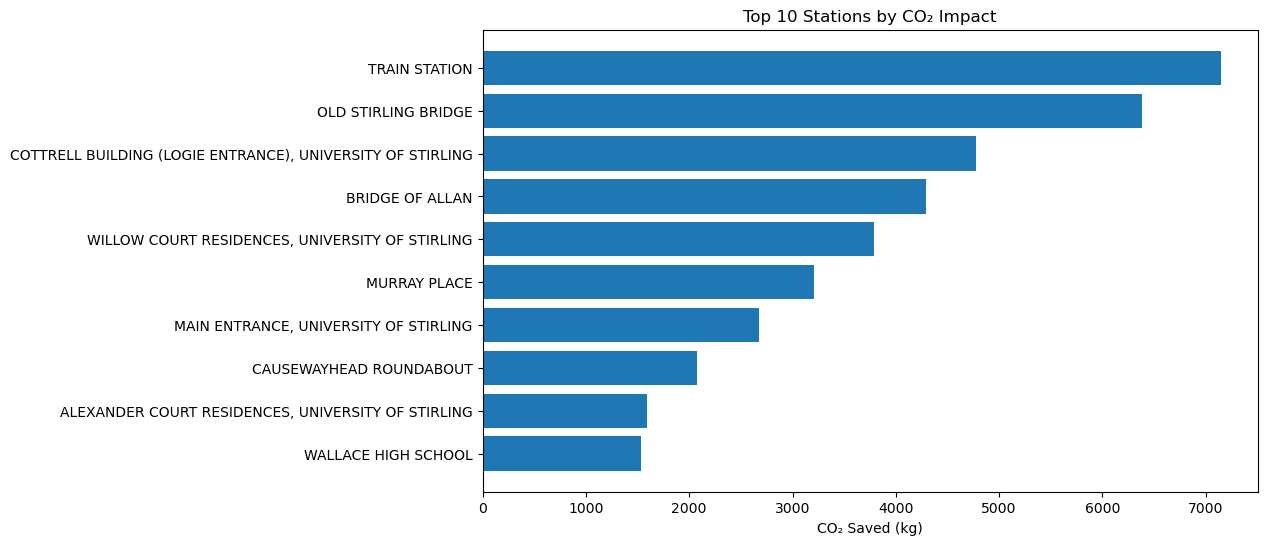

In [631]:
co2_station = (
    df.groupby("rental_place")["co2_saved_kg"]
    .sum()
    .reset_index()
)

top_co2 = co2_station.sort_values(
    "co2_saved_kg", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_co2["rental_place"], top_co2["co2_saved_kg"])
plt.xlabel("CO₂ Saved (kg)")
plt.title("Top 10 Stations by CO₂ Impact")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
peak_returns = (
    df[df["is_peak"] == True]
    .groupby("return_place")
    .size()
    .reset_index(name="peak_returns")
)

In [ ]:
peak_returns = (
    df[df["is_peak"] == True]
    .groupby("return_place")
    .size()
    .reset_index(name="peak_returns")
)


In [ ]:
behaviour_df = stations.merge(
    peak_returns, left_on="station", right_on="return_place", how="left"
).fillna(0)


In [ ]:
behaviour_df["EASY"] = behaviour_df["peak_net_flow"] > 0
behaviour_df["ATTRACTIVE"] = behaviour_df["peak_net_flow"] > 1
behaviour_df["SOCIAL"] = behaviour_df["station"].str.contains("UNIVERSITY|CAMPUS")
behaviour_df["TIMELY"] = behaviour_df["peak_net_flow"] > 0


In [ ]:
behaviour_df["recommended_nudge"] = np.where(
    behaviour_df["peak_net_flow"] > 0,
    "Offer peak-time return rewards & CO₂ feedback",
    "Maintain current operations"
)


In [ ]:
kpis = pd.DataFrame({
    "KPI": [
        "Average trips per bike per day",
        "Peak-time availability rate",
        "Redistribution efficiency",
        "CO₂ saved per month",
        "Behavioural uptake rate"
    ],
    "Definition": [
        "Trips ÷ fleet size ÷ days",
        "Trips completed during peak ÷ attempted trips",
        "Bikes successfully reallocated ÷ bikes required",
        "Total CO₂ saved from substituted car trips",
        "% of users responding to incentives"
    ]
})


In [ ]:
behaviour_df.to_csv(
    "nextbike_behavioural_interventions.csv", index=False
)

kpis.to_csv(
    "nextbike_kpi_framework.csv", index=False
)


In [ ]:
import os
print(os.getcwd())
